## (1) open the required libraries

In [1]:
import pandas as pd
import numpy as np 

import os 

import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go 

import seaborn as sns 

import matplotlib.pyplot as plt 

import warnings


## (2) read data file after downloading it from keegel site 

In [2]:
df= pd.read_csv("loan_risk_prediction_dataset.csv")

## (3)EDA and data preprocessing(simple)

In [3]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [4]:
df.info()

# there is missing value we should handle 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [5]:
df.isnull().sum()


Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [6]:
df.isnull().sum().sort_values(ascending=False)



Education          198
Income             196
CreditScore        194
Age                  0
LoanAmount           0
YearsExperience      0
Gender               0
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [7]:
df.isnull().sum() / df.shape[0] * 100
# not exceed 10% of the full data 

Age                0.00
Income             3.92
LoanAmount         0.00
CreditScore        3.88
YearsExperience    0.00
Gender             0.00
Education          3.96
City               0.00
EmploymentType     0.00
LoanApproved       0.00
dtype: float64

In [8]:
df[df.isnull().any(axis=1)]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
7,56,NaN,6279.0,599.0,22,Male,PhD,New York,Unemployed,0
13,53,48699.0,20554.0,NaN,22,Female,NaN,Chicago,Self-Employed,0
14,57,NaN,13834.0,639.0,31,Male,Masters,San Francisco,Salaried,1
19,41,NaN,5867.0,466.0,12,Male,Bachelors,Houston,Unemployed,0
...,...,...,...,...,...,...,...,...,...,...
4963,27,NaN,15482.0,555.0,32,Female,PhD,Houston,Unemployed,0
4977,42,NaN,17577.0,553.0,6,Female,High School,New York,Self-Employed,0
4993,62,68099.0,25124.0,NaN,35,Male,Bachelors,Houston,Unemployed,0
4995,24,36780.0,23383.0,NaN,23,Male,Masters,Houston,Salaried,0


In [9]:
df.duplicated().sum()
#good no duplicate data 

np.int64(0)

### deal with missing values & data errors

In [10]:
df.describe(include='object')
#education has missing value , categorical , 

,Gender,Education,City,EmploymentType
count,5000,4802,5000,5000
unique,2,4,4,3
top,Male,Bachelors,Chicago,Self-Employed
freq,2541,1220,1304,1730


In [11]:
#df['Education'].value_counts()
#close count , not very dominant value just close to eachother (no simple imputer no mode ) better drop that small amount to not affect the data 

In [12]:
#df.dropna(subset=['Education'],axis=0,inplace=True)

In [13]:
#education isnot so related to loan approved or not first because if not i can drop the whole column from the begin so i wonot lost data 
#and at the same time keep 

In [14]:
px.histogram(df,x='Education' , y='LoanApproved')
# actually no relation all get a close number of loan approved so no hurm if i drop the all column for ot affect data 

In [15]:
df.drop(columns=['Education'], inplace=True)

In [16]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,Chicago,Unemployed,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   City             5000 non-null   object 
 7   EmploymentType   5000 non-null   object 
 8   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 351.7+ KB


In [18]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [19]:
df.describe()
# income and creditscore is skewend , mean isnot the most right 
#income with minus , loanamount in minus !

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [20]:
df['Income'] = df['Income'].apply(lambda x: np.nan if x < 0 else x)

In [21]:
df.isnull().sum()

Age                  0
Income             199
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [22]:
df['LoanAmount'] = df['LoanAmount'].apply(lambda x: np.nan if x < 0 else x)

In [23]:
df.isnull().sum()

Age                  0
Income             199
LoanAmount          28
CreditScore        194
YearsExperience      0
Gender               0
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [24]:
df['Income'] = df.groupby('LoanApproved')['Income'].transform(
    lambda x: x.fillna(x.median()))

In [25]:
df.isnull().sum()

Age                  0
Income               0
LoanAmount          28
CreditScore        194
YearsExperience      0
Gender               0
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [26]:
df['Income_bin'] = pd.qcut(df['Income'], 5)
# devide income imto categorie 

In [27]:
df['CreditScore'] = df.groupby(['LoanApproved', 'Income_bin'])['CreditScore'].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\User\AppData\Local\Temp\ipykernel_14700\3792479706.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [28]:
df.isnull().sum()

Age                 0
Income              0
LoanAmount         28
CreditScore         0
YearsExperience     0
Gender              0
City                0
EmploymentType      0
LoanApproved        0
Income_bin          0
dtype: int64

In [29]:
df['Income_bin'] = pd.qcut(df['Income'], 5)
df['CreditScore_bin'] = pd.qcut(df['CreditScore'], 5)

In [30]:
df['LoanAmount'] = df.groupby(['LoanApproved','Income_bin','CreditScore_bin'])['LoanAmount'].transform(
    lambda x: x.fillna(x.median())
)

C:\Users\User\AppData\Local\Temp\ipykernel_14700\766751362.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [31]:
df.isnull().sum()

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
City               0
EmploymentType     0
LoanApproved       0
Income_bin         0
CreditScore_bin    0
dtype: int64

In [32]:
#df.drop(columns=['Income_bin', 'CreditScore_bin'], inplace=True)

In [33]:
df.describe()
#done

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.584600,49739.613700,19998.764600,573.324500,19.599000,0.230200
std,14.919094,14755.700922,7862.196907,158.016298,11.516837,0.421003
min,18.000000,129.000000,4.000000,300.000000,0.000000,0.000000
25%,31.000000,40036.000000,14599.750000,440.000000,10.000000,0.000000
50%,43.000000,49053.000000,19891.500000,571.000000,20.000000,0.000000
75%,56.000000,59447.000000,25326.750000,706.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [34]:
df.isnull().sum()

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
City               0
EmploymentType     0
LoanApproved       0
Income_bin         0
CreditScore_bin    0
dtype: int64

In [35]:
#from sklearn.impute import KNNImputer
#imputer = KNNImputer()

In [36]:
#df['CreditScore'] = imputer.fit_transform(df[['CreditScore']])
#df['CreditScore'].isnull().sum()

In [37]:
#df.isnull().sum()

In [38]:
#df.info()

### data cleaning and cleansing if needed

In [39]:
df['Age'].value_counts()

Age
66    118
64    118
52    114
43    112
25    110
38    109
54    109
62    109
45    108
51    106
34    105
68    104
46    104
39    104
42    104
50    103
21    103
58    102
53    101
49    101
40    100
61     99
41     99
28     98
29     97
19     97
37     97
23     97
22     95
20     95
57     95
47     95
56     94
36     94
18     93
30     92
31     91
32     91
35     90
26     89
27     88
55     88
69     87
67     84
63     81
44     80
65     79
59     78
33     78
24     74
60     72
48     69
Name: count, dtype: int64

In [40]:
df['Age'].min() , df['Age'].max()
#normal

(np.int64(18), np.int64(69))

In [41]:
df['Income'].value_counts()

Income
47641.5    151
53234.0     49
55656.0      3
53322.0      3
56502.0      3
          ... 
33585.0      1
41178.0      1
33737.0      1
81751.0      1
58928.0      1
Name: count, Length: 4597, dtype: int64

In [42]:
df['Income'].min() , df['Income'].max()
#normal 

(np.float64(129.0), np.float64(99146.0))

In [43]:
df['LoanAmount'].value_counts()

LoanAmount
20573.0    4
21309.0    3
18226.0    3
14623.0    3
26399.0    3
          ..
17423.0    1
10772.0    1
32540.0    1
16154.0    1
23615.0    1
Name: count, Length: 4568, dtype: int64

In [44]:
df['LoanAmount'].min() , df['LoanAmount'].max()
# normal as numeric but some values is too low need check


(np.float64(4.0), np.float64(48353.0))

In [45]:
df[df['LoanAmount'] < 1000]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,City,EmploymentType,LoanApproved,Income_bin,CreditScore_bin
511,39,54476.0,34.0,365.0,19,Female,Chicago,Salaried,0,"(53002.8, 62155.8]","(299.999, 410.0]"
1191,20,56254.0,45.0,569.0,20,Female,Chicago,Unemployed,0,"(53002.8, 62155.8]","(520.0, 626.0]"
1314,28,48201.0,589.0,408.0,9,Male,Chicago,Self-Employed,0,"(46213.2, 53002.8]","(299.999, 410.0]"
2239,58,81607.0,518.0,402.0,38,Female,San Francisco,Salaried,0,"(62155.8, 99146.0]","(299.999, 410.0]"
2340,36,47000.0,220.0,384.0,5,Female,Chicago,Salaried,0,"(46213.2, 53002.8]","(299.999, 410.0]"
2376,36,38737.0,115.0,840.0,17,Male,San Francisco,Unemployed,0,"(37812.6, 46213.2]","(736.2, 849.0]"
2417,45,36772.0,52.0,620.0,22,Male,New York,Self-Employed,0,"(128.999, 37812.6]","(520.0, 626.0]"
2490,59,36478.0,172.0,785.0,38,Female,New York,Self-Employed,0,"(128.999, 37812.6]","(736.2, 849.0]"
2717,38,73240.0,255.0,529.0,29,Male,Houston,Self-Employed,0,"(62155.8, 99146.0]","(520.0, 626.0]"
2754,62,32485.0,455.0,391.0,37,Female,San Francisco,Self-Employed,0,"(128.999, 37812.6]","(299.999, 410.0]"


In [46]:
df[df['LoanAmount'] < 2000]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,City,EmploymentType,LoanApproved,Income_bin,CreditScore_bin
59,61,44358.0,1395.0,691.0,8,Male,New York,Self-Employed,1,"(37812.6, 46213.2]","(626.0, 736.2]"
87,57,50215.0,1779.0,815.0,25,Female,Chicago,Unemployed,0,"(46213.2, 53002.8]","(736.2, 849.0]"
146,43,68667.0,1895.0,384.0,24,Female,San Francisco,Salaried,0,"(62155.8, 99146.0]","(299.999, 410.0]"
173,49,27936.0,1138.0,585.0,35,Male,Chicago,Unemployed,0,"(128.999, 37812.6]","(520.0, 626.0]"
511,39,54476.0,34.0,365.0,19,Female,Chicago,Salaried,0,"(53002.8, 62155.8]","(299.999, 410.0]"
618,49,47641.5,1293.0,351.0,36,Female,New York,Salaried,0,"(46213.2, 53002.8]","(299.999, 410.0]"
992,64,47376.0,1555.0,369.0,39,Male,New York,Self-Employed,0,"(46213.2, 53002.8]","(299.999, 410.0]"
1191,20,56254.0,45.0,569.0,20,Female,Chicago,Unemployed,0,"(53002.8, 62155.8]","(520.0, 626.0]"
1314,28,48201.0,589.0,408.0,9,Male,Chicago,Self-Employed,0,"(46213.2, 53002.8]","(299.999, 410.0]"
2239,58,81607.0,518.0,402.0,38,Female,San Francisco,Salaried,0,"(62155.8, 99146.0]","(299.999, 410.0]"


In [47]:
df[df['LoanAmount'] < 500]
#loanamount has outliers need to be handled alot of data error 

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,City,EmploymentType,LoanApproved,Income_bin,CreditScore_bin
511,39,54476.0,34.0,365.0,19,Female,Chicago,Salaried,0,"(53002.8, 62155.8]","(299.999, 410.0]"
1191,20,56254.0,45.0,569.0,20,Female,Chicago,Unemployed,0,"(53002.8, 62155.8]","(520.0, 626.0]"
2340,36,47000.0,220.0,384.0,5,Female,Chicago,Salaried,0,"(46213.2, 53002.8]","(299.999, 410.0]"
2376,36,38737.0,115.0,840.0,17,Male,San Francisco,Unemployed,0,"(37812.6, 46213.2]","(736.2, 849.0]"
2417,45,36772.0,52.0,620.0,22,Male,New York,Self-Employed,0,"(128.999, 37812.6]","(520.0, 626.0]"
2490,59,36478.0,172.0,785.0,38,Female,New York,Self-Employed,0,"(128.999, 37812.6]","(736.2, 849.0]"
2717,38,73240.0,255.0,529.0,29,Male,Houston,Self-Employed,0,"(62155.8, 99146.0]","(520.0, 626.0]"
2754,62,32485.0,455.0,391.0,37,Female,San Francisco,Self-Employed,0,"(128.999, 37812.6]","(299.999, 410.0]"
3545,44,35371.0,187.0,425.0,21,Male,Chicago,Self-Employed,0,"(128.999, 37812.6]","(410.0, 520.0]"
3607,58,45628.0,4.0,810.0,29,Female,Chicago,Unemployed,0,"(37812.6, 46213.2]","(736.2, 849.0]"


<Axes: xlabel='LoanAmount'>

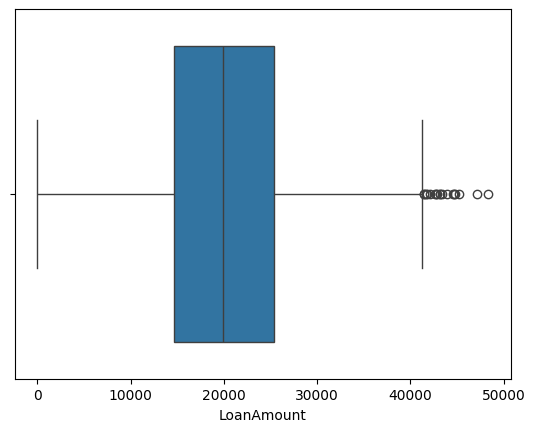

In [48]:
sns.boxplot(x='LoanAmount', data=df)

In [49]:
df[df['LoanAmount'] > 42000]
#normal 


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,City,EmploymentType,LoanApproved,Income_bin,CreditScore_bin
453,69,28985.0,43891.0,410.0,19,Male,Houston,Unemployed,1,"(128.999, 37812.6]","(299.999, 410.0]"
833,20,53789.0,47185.0,619.0,29,Male,Chicago,Self-Employed,1,"(53002.8, 62155.8]","(520.0, 626.0]"
1227,32,50132.0,43133.0,633.0,11,Male,New York,Self-Employed,1,"(46213.2, 53002.8]","(626.0, 736.2]"
1438,38,59941.0,45197.0,501.0,3,Female,San Francisco,Salaried,0,"(53002.8, 62155.8]","(410.0, 520.0]"
1593,66,50432.0,48353.0,814.0,22,Female,San Francisco,Salaried,1,"(46213.2, 53002.8]","(736.2, 849.0]"
2321,60,55732.0,42101.0,471.0,17,Female,San Francisco,Unemployed,1,"(53002.8, 62155.8]","(410.0, 520.0]"
2958,67,59640.0,43336.0,558.0,7,Male,San Francisco,Unemployed,1,"(53002.8, 62155.8]","(520.0, 626.0]"
3745,36,51626.0,42829.0,377.0,11,Male,New York,Self-Employed,0,"(46213.2, 53002.8]","(299.999, 410.0]"
3902,41,56044.0,44827.0,501.0,25,Female,New York,Unemployed,0,"(53002.8, 62155.8]","(410.0, 520.0]"
4021,55,41069.0,42671.0,624.0,18,Female,San Francisco,Self-Employed,1,"(37812.6, 46213.2]","(520.0, 626.0]"


In [50]:
Q1 = df['LoanAmount'].quantile(0.25)
Q1
# MINOR THAN THAT NEED CHECK 

np.float64(14599.75)

In [51]:
Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

df[df['LoanAmount'] < lower_bound]
#mathematically not exist but with eyes and logic it is not right data so i prefer delete  them and let what after 1000 dollar loans as they are only 21 and if i fil them it will affect loan approved that already refused requirement 
#so i habe to fill both with median so it can be correct and not affect the data 

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,City,EmploymentType,LoanApproved,Income_bin,CreditScore_bin


In [52]:
df['LoanApproved'].median()
#as median is zero and max of them are zero so i can do data correction without need to change to median especially that most of them are self employed or no employed 
#logically refuse have another reason even if salary is fine but model will be better

np.float64(0.0)

In [53]:
df.loc[df['LoanAmount'] < 1000, 'LoanAmount'] = np.nan

In [54]:
df['LoanAmount'] = df.groupby(['LoanApproved','CreditScore_bin'])['LoanAmount'].transform(
    lambda x: x.fillna(x.median())
)


C:\Users\User\AppData\Local\Temp\ipykernel_14700\2983877302.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Age              5000 non-null   int64   
 1   Income           5000 non-null   float64 
 2   LoanAmount       5000 non-null   float64 
 3   CreditScore      5000 non-null   float64 
 4   YearsExperience  5000 non-null   int64   
 5   Gender           5000 non-null   object  
 6   City             5000 non-null   object  
 7   EmploymentType   5000 non-null   object  
 8   LoanApproved     5000 non-null   int64   
 9   Income_bin       5000 non-null   category
 10  CreditScore_bin  5000 non-null   category
dtypes: category(2), float64(3), int64(3), object(3)
memory usage: 361.9+ KB


In [56]:
df.isnull().sum()

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
City               0
EmploymentType     0
LoanApproved       0
Income_bin         0
CreditScore_bin    0
dtype: int64

In [57]:
df.drop(columns=['Income_bin', 'CreditScore_bin'], inplace=True)

In [58]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,Chicago,Unemployed,0


In [59]:
df['CreditScore'].value_counts()

CreditScore
478.0    63
538.0    46
501.0    45
585.0    43
495.0    41
         ..
491.0     3
629.5     2
567.0     2
319.0     1
714.5     1
Name: count, Length: 552, dtype: int64

In [60]:
df['CreditScore'].min() , df['CreditScore'].max()
#normal

(np.float64(300.0), np.float64(849.0))

In [61]:
df['YearsExperience'].value_counts()

YearsExperience
12    154
36    153
22    144
14    144
34    143
8     141
2     138
3     137
37    136
15    135
20    133
25    132
10    131
4     131
31    131
27    131
23    128
28    128
35    127
21    125
24    124
18    124
39    121
29    119
0     117
32    117
19    117
38    116
1     116
13    116
11    116
17    116
16    115
26    113
7     111
30    109
9     108
6     106
5     101
33     96
Name: count, dtype: int64

In [62]:
df['YearsExperience'].min(),df['YearsExperience'].max()
#normal

(np.int64(0), np.int64(39))

In [63]:
df['Gender'].value_counts()
#BALANCE

Gender
Male      2541
Female    2459
Name: count, dtype: int64

In [64]:
df['EmploymentType'].value_counts()
#balance

EmploymentType
Self-Employed    1730
Unemployed       1660
Salaried         1610
Name: count, dtype: int64

In [65]:
df['City'].value_counts()
#balance

City
Chicago          1304
San Francisco    1257
Houston          1232
New York         1207
Name: count, dtype: int64

In [66]:
df['LoanApproved'].value_counts()
#imbalance

LoanApproved
0    3849
1    1151
Name: count, dtype: int64

# 5) Analyzation and statistics

In [67]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='object')

In [68]:
px.bar(
    df,
    x='LoanApproved',
    y='Income',
    color='LoanApproved',
    title='Mean Income by Loan Approval',
    color_discrete_sequence=['#EF553B', '#636EFA']
)


In [69]:
px.bar(df, x='LoanApproved', y='LoanAmount', title='Mean Loan Amount')

In [70]:
px.bar(df, x='LoanApproved', y='CreditScore', title='Mean Credit Score')

In [71]:
approval_rate = df.groupby('LoanApproved').size().reset_index(name='count')

px.pie(approval_rate, names='LoanApproved', values='count', title='Loan Approval Rate')


In [72]:
px.scatter(df, x='Income', y='LoanAmount', color='LoanApproved',
                 title='Income vs Loan Amount')

# income regarding loan amount 

In [73]:
emp_rate = df.groupby('EmploymentType')['LoanApproved'].mean().reset_index()

px.bar(emp_rate, x='EmploymentType', y='LoanApproved',
             title='Loan Approval Rate by Employment Type',
             color='EmploymentType')
#yes employment type effect approve

In [74]:
px.box(df, x='LoanApproved', y='CreditScore',
             title='Credit Score Distribution by Loan Approval')

#Credit Score Distribution by Approval

In [75]:
px.scatter(df, x='CreditScore', y='LoanAmount',
                 color='LoanApproved',
                 title='Credit Score vs Loan Amount (Risk Pattern)')

In [76]:
city_loan = df.groupby('City')['LoanAmount'].mean().reset_index()

px.bar(city_loan, x='City', y='LoanAmount',
             title='Average Loan Amount by City',
             color='City')

#no matter city 

In [77]:
corr = df[['Age','Income','LoanAmount','CreditScore','YearsExperience','LoanApproved']].corr()

px.imshow(corr, text_auto=True,
                title='Feature Correlation Heatmap')

In [78]:
px.scatter_3d(
    df,
    x='Income',
    y='LoanAmount',
    z='CreditScore',

    color='LoanApproved',

    title='Income, Loan Amount and Credit Score vs Loan Approval',

    color_discrete_map={
        0: '#EF553B',
        1: '#00CC96'
    },

    template='plotly_dark'
)

# 5) data preprocessing for model & AI

In [79]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='object')

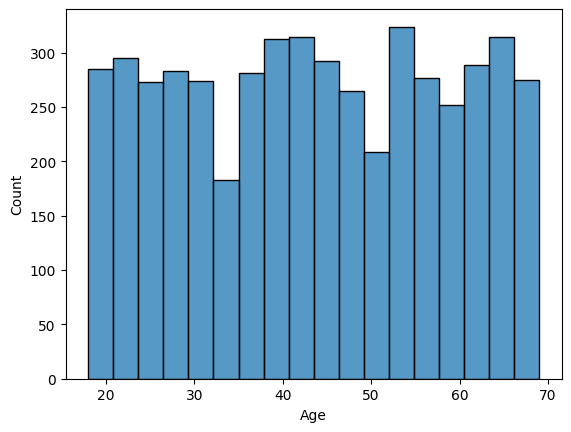

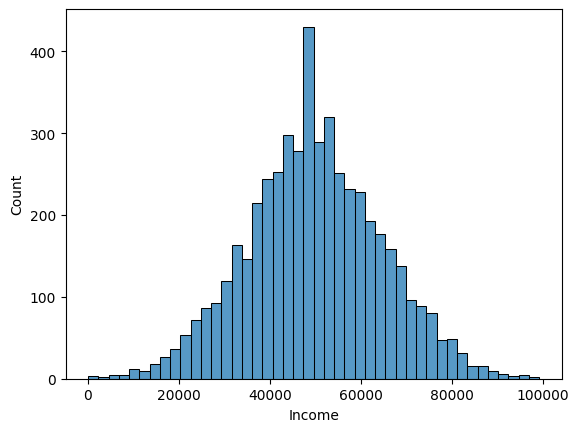

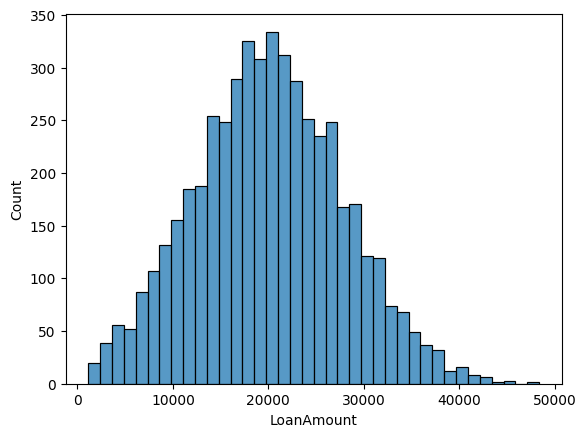

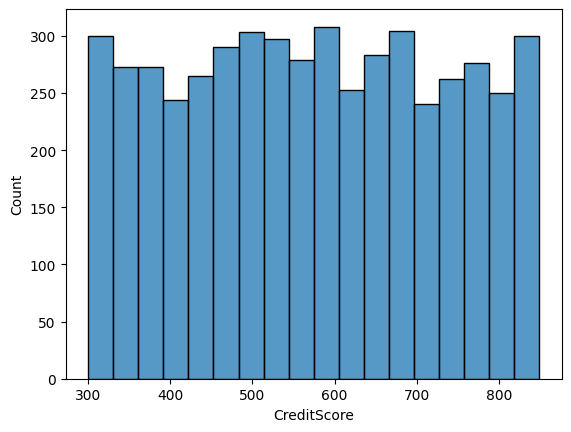

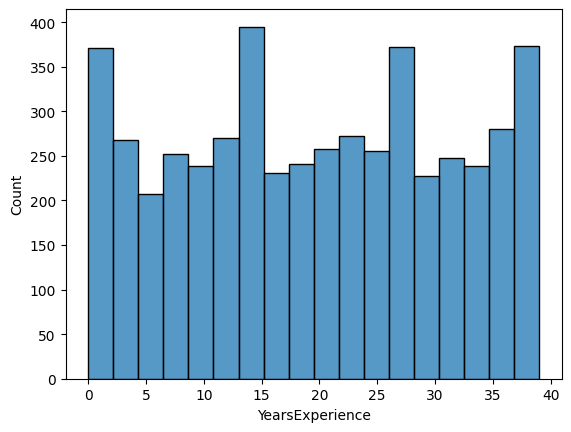

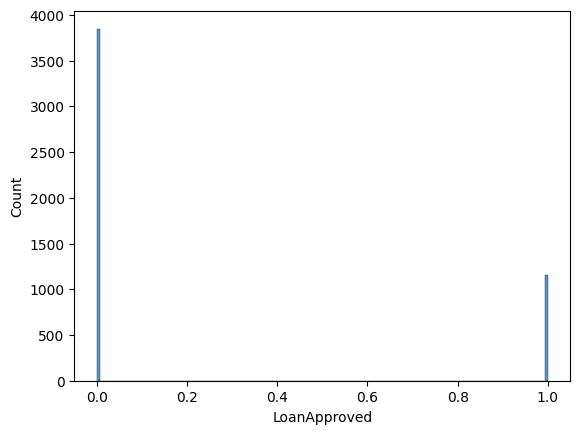

In [80]:
for col in df.select_dtypes('number').columns :
    plt.figure()
    sns.histplot(df[col])

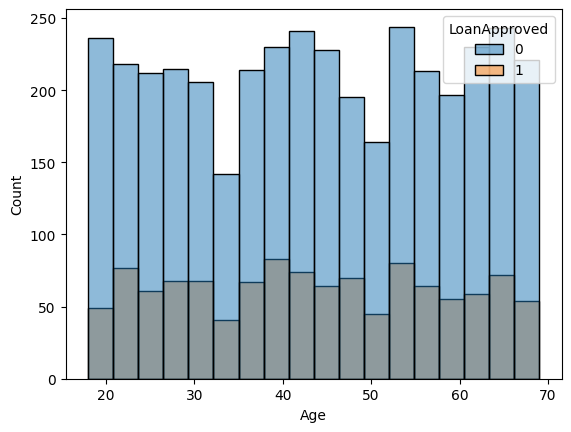

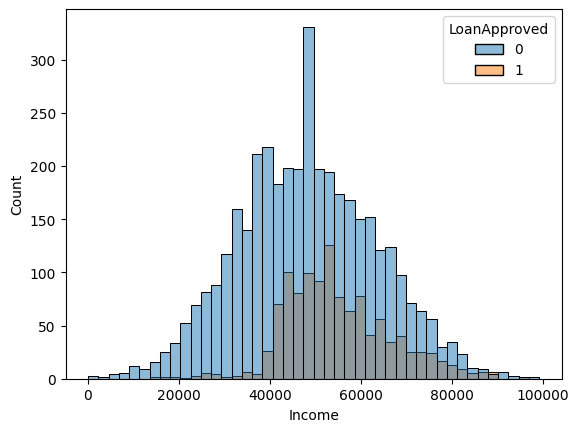

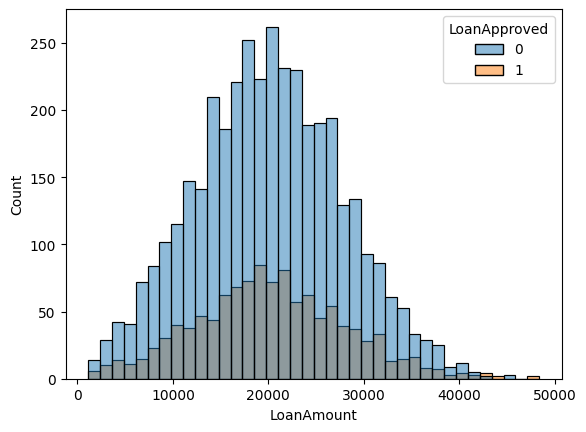

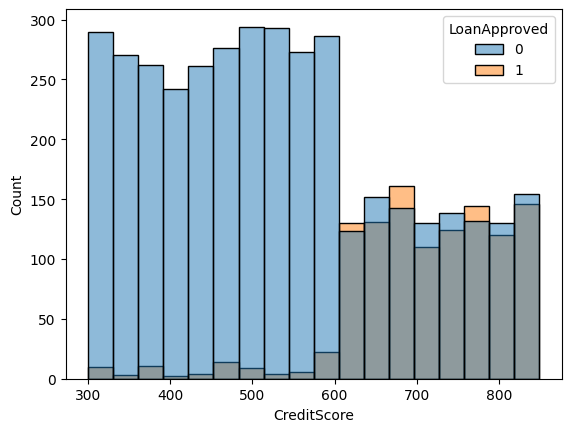

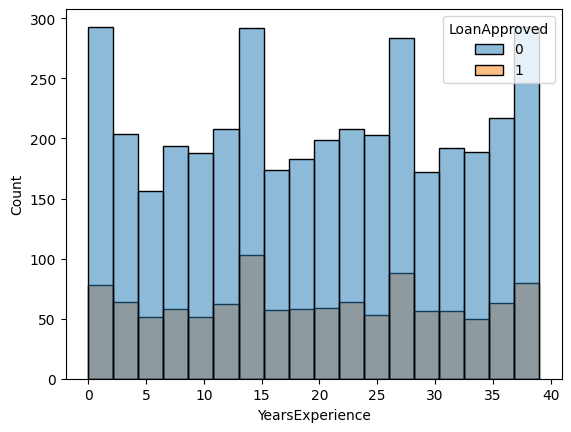

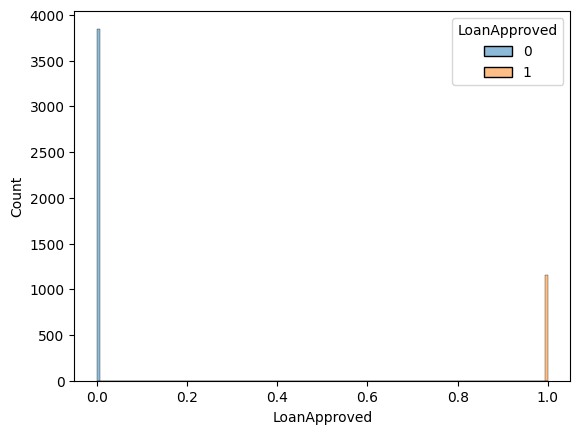

In [81]:
for col in df.select_dtypes('number').columns :
    plt.figure()
    sns.histplot(data = df , x = df[col] , hue = 'LoanApproved')

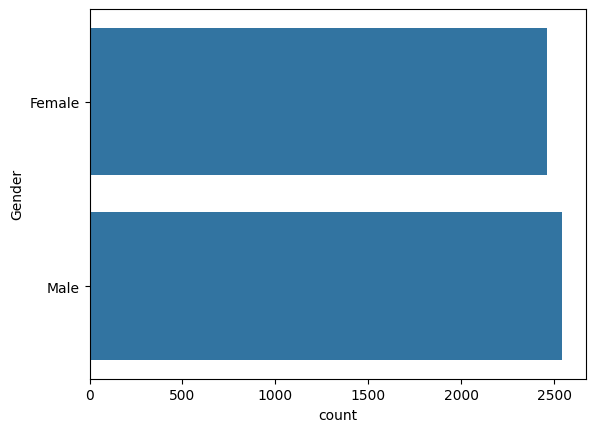

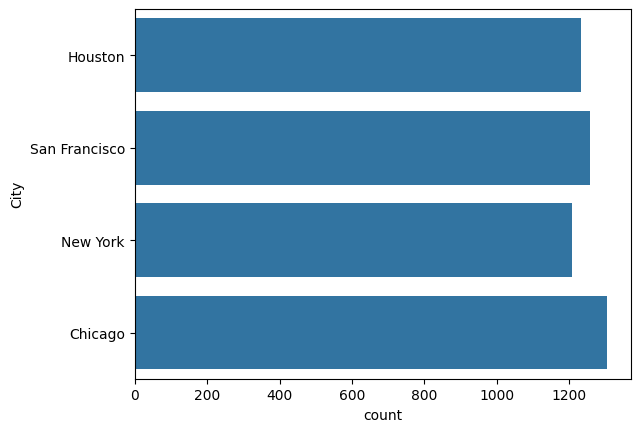

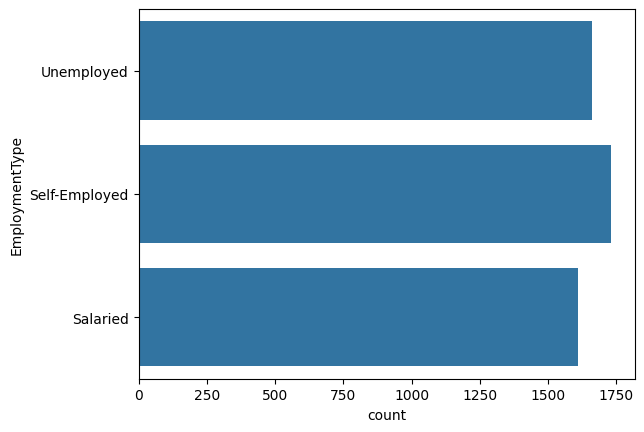

In [82]:
for col in df.select_dtypes('O').columns:
    plt.figure()
    sns.countplot(df[col])

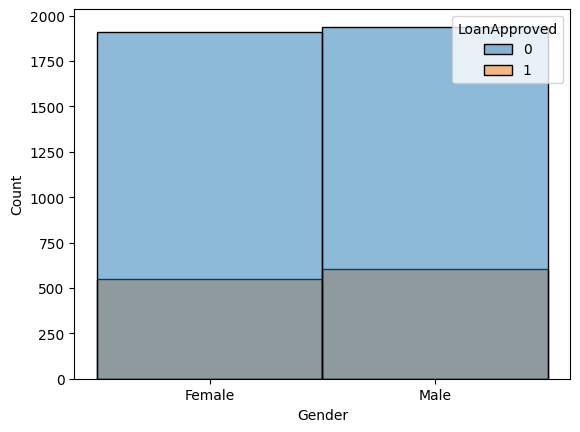

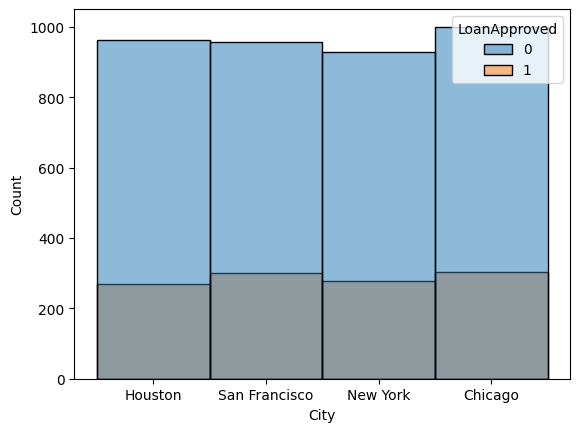

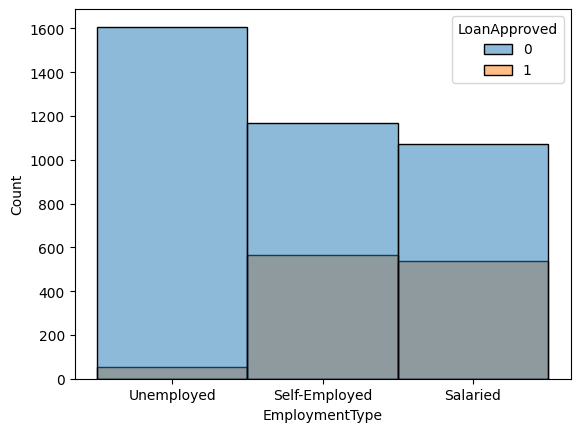

In [83]:
for col in df.select_dtypes('O').columns :
    plt.figure()
    sns.histplot(data = df , x = df[col] , hue = 'LoanApproved')

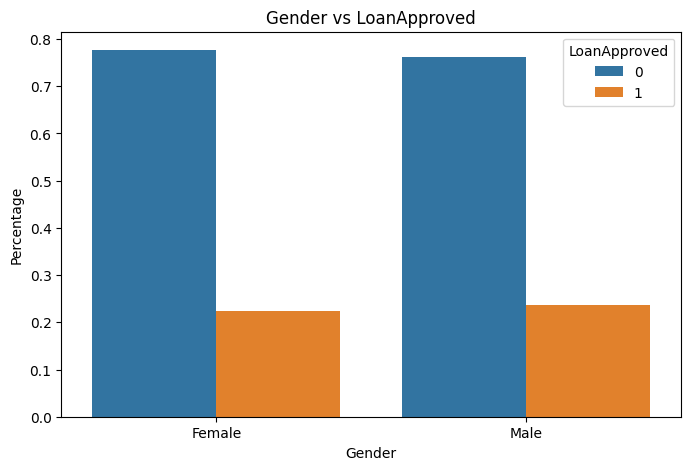

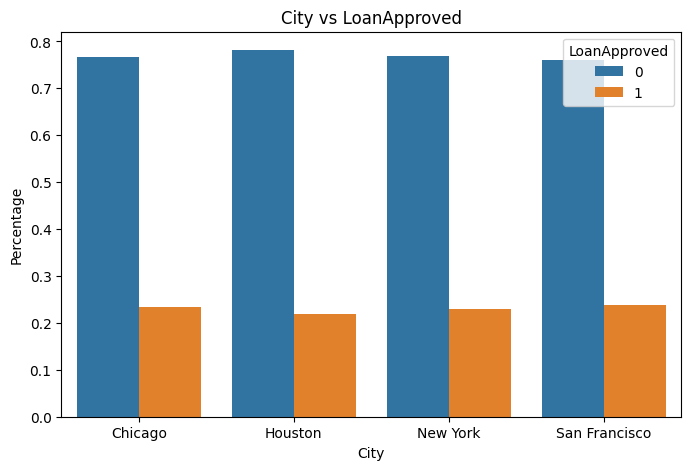

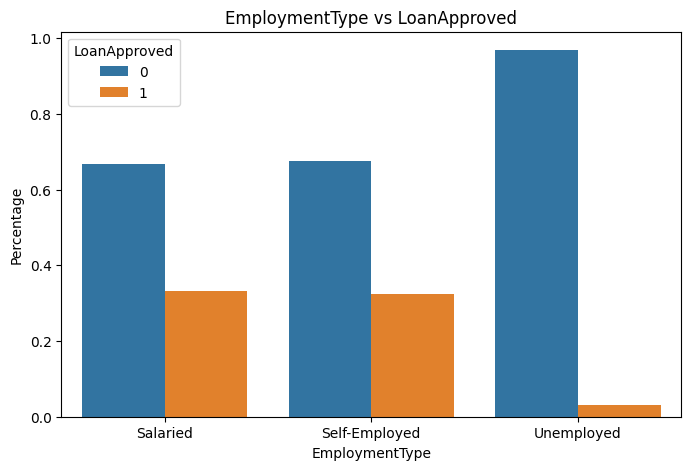

In [84]:
for col in df.select_dtypes('O').columns:
    
    plt.figure(figsize=(8,5))
    
    temp = (
        df.groupby(col)['LoanApproved']
        .value_counts(normalize=True)
        .rename('ratio')
        .reset_index()
    )

    sns.barplot(
        data=temp,
        x=col,
        y='ratio',
        hue='LoanApproved'
    )

    plt.title(f'{col} vs LoanApproved')
    plt.ylabel('Percentage')
    plt.show()

In [85]:
df.groupby('Gender')['LoanApproved'].mean()

# القيم قريبه جدا و علي الشارت مفيش فرق نهائي في قبول القرض فهحذفه

Gender
Female    0.223261
Male      0.236915
Name: LoanApproved, dtype: float64

In [86]:
df.groupby('City')['LoanApproved'].mean()
# نفس الفكره علي الشارت متساوي تقريبا في نسبه القبول حسب المدينه متغيرتش و المتوسط قريب جدا لاداعي لوجوده 


City
Chicago          0.233129
Houston          0.218344
New York         0.230323
San Francisco    0.238663
Name: LoanApproved, dtype: float64

In [87]:
#for col in ['Gender', 'City']:

    
    #print(f'\n{col}')

    #print(
        #df.groupby(col)['LoanApproved']
        #.mean()
        #.sort_values(ascending=False)
    #)

In [88]:
df.drop(columns=['Gender', 'City'], inplace=True)

In [89]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Unemployed,0


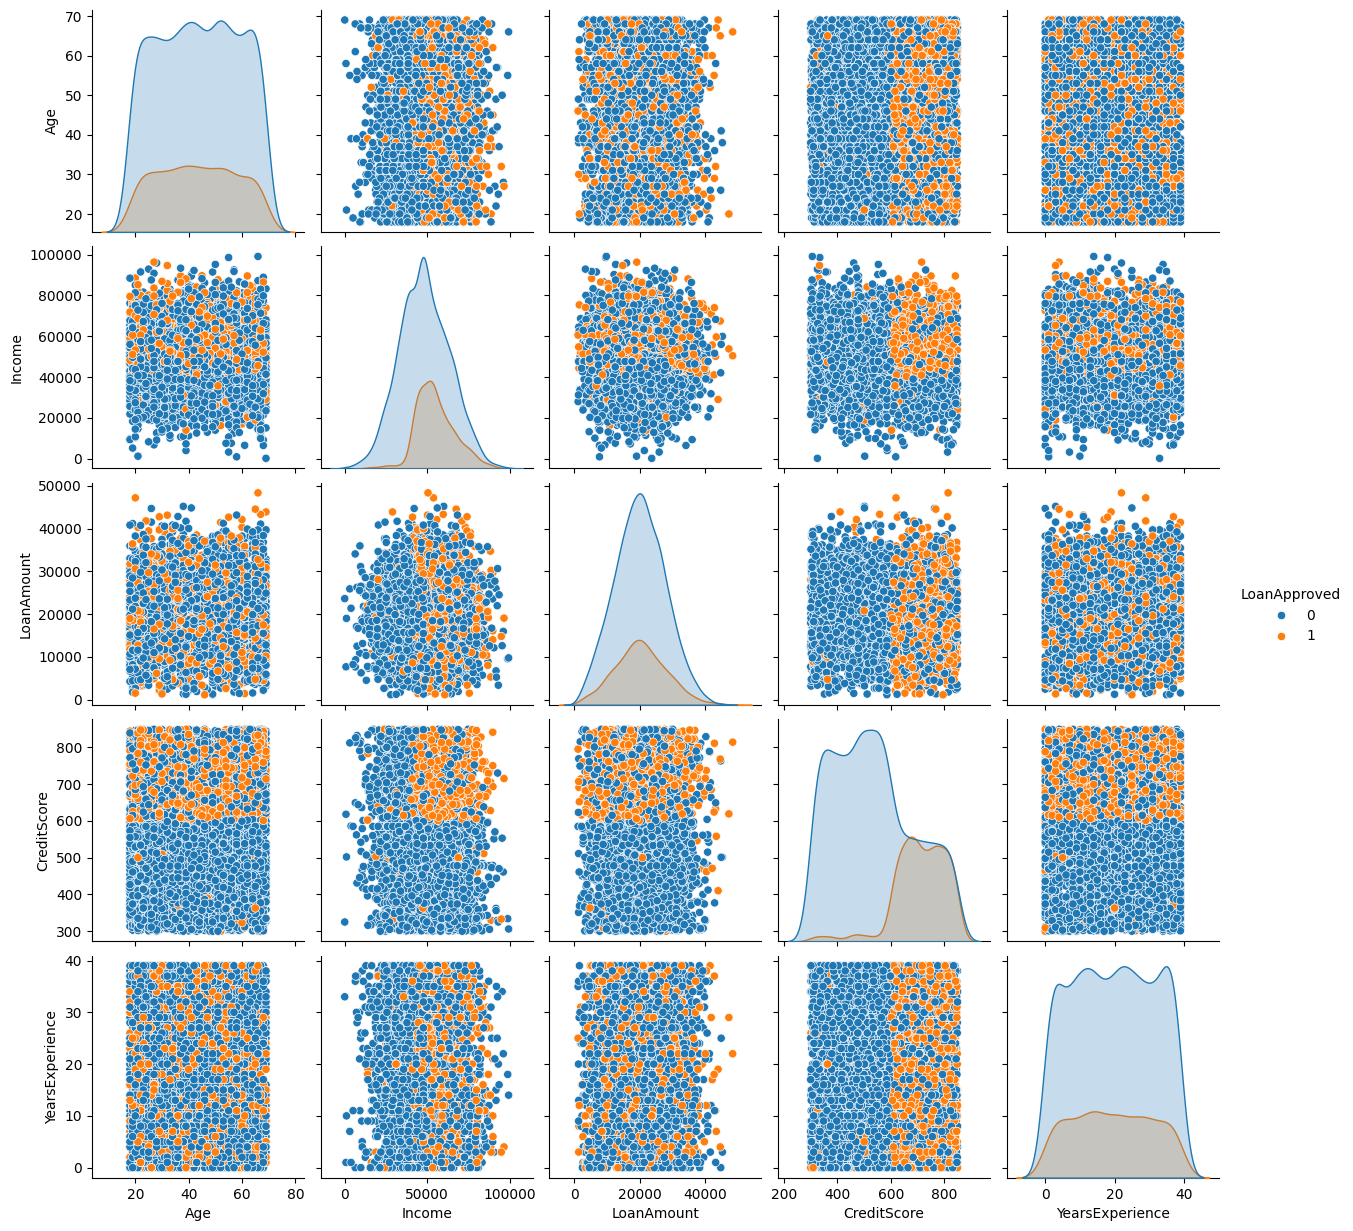

In [90]:
sns.pairplot(data = df ,hue = 'LoanApproved' )

#### SMOTE ( JUST IN CASE I NEED IT TO ENHANCE THE MODEL ) WE WILL SEE & EVALUATE 

In [91]:
df['LoanApproved'].value_counts(normalize=True) * 100
# احنا عملناها فوق قبل كده بس هنعيد تاني عشان نقدر نحلل مظبوط 

LoanApproved
0    76.98
1    23.02
Name: proportion, dtype: float64

In [92]:
df['EmploymentType'].value_counts(normalize=True) * 100


EmploymentType
Self-Employed    34.6
Unemployed       33.2
Salaried         32.2
Name: proportion, dtype: float64

In [93]:
# انا هحضر الكود بس هجربه بعد ما اجرب الموديل من غير smote  لاني شايف ان ممكن الداتا مش تحتاج 
#from imblearn.over_sampling import SMOTE
#from sklearn.model_selection import train_test_split

# 1. Split data (IMPORTANT: before SMOTE)
#X , y = df[df.columns [:-1]] , df['LoanApproved']
#X_train, X_test, y_train, y_test = train_test_split(
   # X,
   # y,
   # test_size=0.2,
    #random_state=42,
   # stratify=y
#)

# 2. Apply SMOTE ONLY on training data
#smote = SMOTE(random_state=42)

#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3. Check distribution
#print("Before SMOTE:")
#print(y_train.value_counts())

#print("\nAfter SMOTE:")
#print(y_train_smote.value_counts())

#### TRAIN TEST SPLIT & ENCODING & SCALING 

In [94]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Unemployed,0


In [95]:
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.compose import ColumnTransformer 

from sklearn.model_selection import train_test_split

In [96]:
x = df.drop('LoanApproved', axis=1)
y = df['LoanApproved']

In [97]:
num_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']
cat_features = ['EmploymentType']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(), cat_features)
    ])

In [98]:
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [99]:
#x_processed = preprocess.fit_transform(x)

In [100]:
#x_processed

In [101]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [102]:
x_train_processed = preprocess.fit_transform(x_train)
x_test_processed = preprocess.transform(x_test)

# models

In [103]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

from sklearn.svm import SVC

####  accuracy Measures the overall correctness of predictions by calculating the ratio of correct predictions to total predictions.
Useful for balanced datasets, but can be misleading in imbalanced data.
#### f1 Harmonic mean of Precision and Recall, balancing both false positives and false negatives.
Best metric for imbalanced classification problems like loan approval.
#### precision Measures how many of the predicted positive cases are actually correct.
Important when false positives are costly (e.g., approving risky loans).
#### recall Measures how many actual positive cases were correctly identified.
Important when missing positive cases is risky (e.g., rejecting good applicants).
#### roc-auc Evaluates model’s ability to distinguish between classes across all thresholds.
Best for comparing models in binary classification regardless of threshold choice.

In [104]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),

        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred),

        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),

        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),

        "Train ROC-AUC": roc_auc_score(y_train, train_pred),
        "Test ROC-AUC": roc_auc_score(y_test, test_pred),
    }

In [133]:
def run_models_processed(x_train_processed, x_test_processed, y_train, y_test):

    results = []

    # ================= Logistic Regression =================
    lr = LogisticRegression(max_iter=1000, class_weight='balanced')
    lr.fit(x_train_processed, y_train)
    results.append(evaluate_model(lr, x_train_processed, x_test_processed, y_train, y_test, "Logistic Regression"))

    #max_iter=1000 → Sets maximum iterations for optimization to ensure convergence.
    #class_weight='balanced' → Automatically adjusts weights to handle imbalanced classes.

    # ================= Polynomial Logistic =================
    poly = PolynomialFeatures(degree=3, include_bias=False)

    x_train_poly = poly.fit_transform(x_train_processed)
    x_test_poly = poly.transform(x_test_processed)

    lr_poly = LogisticRegression(max_iter=1000)
    lr_poly.fit(x_train_poly, y_train)

    results.append(evaluate_model(lr_poly, x_train_poly, x_test_poly, y_train, y_test, "Polynomial Logistic"))

    #degree=3 → Defines the complexity of feature interactions by creating polynomial terms up to power 3.
    #include_bias=False → Prevents adding an extra intercept column to avoid redundancy.

    # ================= KNN =================
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(x_train_processed, y_train)

    results.append(evaluate_model(knn, x_train_processed, x_test_processed, y_train, y_test, "KNN"))

    #n_neighbors=5 → Number of nearest samples used to decide the class label.

    # ================= Naive Bayes =================
    nb = GaussianNB()
    nb.fit(x_train_processed, y_train)

    results.append(evaluate_model(nb, x_train_processed, x_test_processed, y_train, y_test, "Naive Bayes"))

    

    # ================= Decision Tree =================
    dt = DecisionTreeClassifier(max_depth=6, random_state=42)
    dt.fit(x_train_processed, y_train)

    results.append(evaluate_model(dt, x_train_processed, x_test_processed, y_train, y_test, "Decision Tree"))

    #max_depth=6 → Limits tree depth to reduce overfitting and control complexity.

    # ================= Random Forest =================
    rf = RandomForestClassifier(n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2)
    
    rf.fit(x_train_processed, y_train)

    results.append(evaluate_model(rf, x_train_processed, x_test_processed, y_train, y_test, "Random Forest"))

    #n_estimators=300 → Number of decision trees in the forest for stronger averaging.
    #max_depth=8 → Limits depth of each tree to reduce overfitting.
    #min_samples_split=5 → Minimum samples required to split a node.
    #min_samples_leaf=2 → Minimum samples required at a leaf node to avoid overfitting.

    # ================= Gradient Boosting =================
    gb = GradientBoostingClassifier(random_state=42)

    gb.fit(x_train_processed, y_train)

    results.append(evaluate_model(gb, x_train_processed, x_test_processed, y_train, y_test, "Gradient Boosting"))

    #random_state=42 → Ensures reproducibility of results.

    # ================= AdaBoost =================
    ab = AdaBoostClassifier(random_state=42)
    ab.fit(x_train_processed, y_train)

    results.append(evaluate_model(ab, x_train_processed, x_test_processed, y_train, y_test, "AdaBoost"))

    #random_state=42 → Ensures reproducible boosting sequence.


    # ================= SVC =================
    svm = SVC(kernel='rbf', probability=True, class_weight='balanced')
    svm.fit(x_train_processed, y_train)

    results.append(evaluate_model(svm,x_train_processed,x_test_processed,y_train,y_test,"SVM"))

    #kernel='rbf' → Uses Gaussian kernel to handle non-linear decision boundaries.
    #probability=True → Enables probability outputs instead of only class labels.
    #class_weight='balanced' → Handles imbalanced datasets by adjusting class importance.

    


    return pd.DataFrame(results)

#✔️ Logistic Regression
    🔹 max_iter=1000

    يعني عدد محاولات الموديل عشان يوصل للحل النهائي (convergence).
    لو صغير → ممكن الموديل مايكملش التدريب ويطلع warning.

    🔹 class_weight='balanced'

    يعني الموديل يدي وزن أكبر للفئة الأقل (minority class).
    مفيد جدًا مع الداتا غير المتوازنة  (76% vs 23%).

✔️ Polynomial Features
🔹 degree=3

يعني هنزود تعقيد البيانات بإننا نعمل علاقات بين الـ features لحد القوة 3.
مثلاً:

x
x²
x³
وده يساعد الموديل يفهم علاقات غير خطية.
🔹 include_bias=False

يعني ما نضيفش عمود ثابت (1s) لأن الموديل أصلاً بيحسب الـ intercept.

✔️ KNN (K-Nearest Neighbors)
🔹 n_neighbors=5

يعني الموديل لما يجي يتوقع، بيبص على أقرب 5 نقاط حواليه.
وبياخد القرار بناءً على الأغلبية بينهم.

✔️ Decision Tree
🔹 max_depth=6

يعني أقصى عمق للشجرة هو 6 مستويات.
ده بيمنع الشجرة إنها تحفظ الداتا زيادة (overfitting).

✔️ Random Forest
🔹 n_estimators=300

يعني عدد الأشجار داخل الغابة = 300 شجرة..

🔹 max_depth=8

بيحدد أقصى عمق لكل شجرة → يقلل overfitting.

🔹 min_samples_split=5

يعني لازم يكون عندي على الأقل 5 samples عشان أقدر أقسم العقدة.

🔹 min_samples_leaf=2

يعني أقل عدد samples في الورقة (leaf node) = 2.
ده بيخلي النموذج smoother وأقل overfitting.

✔️ Gradient Boosting
🔹 random_state=42

ده بس عشان النتائج تبقى ثابتة كل مرة (reproducibility).
مش بيأثر على الأداء نفسه.

✔️ AdaBoost
🔹 random_state=42

نفس الفكرة: تثبيت النتائج عشان التجارب تبقى قابلة للإعادة.

   SVC (Support Vector Classifier)
🔹 kernel='rbf'

يعني بنستخدم kernel غير خطي (Gaussian)
عشان نقدر نفصل البيانات اللي مش linearly separable.

🔹 probability=True

يعني الموديل يطلع probability (مثلاً 0.8 بدل 0/1).
مهم لو عايز تقييم أو thresholds.

🔹 class_weight='balanced'

زي Logistic Regression → بيعالج imbalance بين الفئات.

In [134]:
results_df= run_models_processed(
    x_train_processed,
    x_test_processed,
    y_train,
    y_test
)


In [135]:
results_df

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.87125,0.852,0.765376,0.735714,0.659341,0.624242,0.912052,0.895652,0.885549,0.867307
1,Polynomial Logistic,0.95300,0.936,0.894263,0.860262,0.927655,0.864035,0.863192,0.856522,0.921528,0.908131
2,KNN,0.95150,0.920,0.890395,0.821429,0.928151,0.844037,0.855592,0.800000,0.917890,0.877922
3,Naive Bayes,0.91025,0.891,0.823760,0.789981,0.751792,0.709343,0.910966,0.891304,0.910501,0.891107
4,Decision Tree,0.97575,0.961,0.946081,0.912360,0.969248,0.944186,0.923996,0.882609,0.957613,0.933512
5,Random Forest,0.97150,0.963,0.936170,0.916854,0.966474,0.948837,0.907709,0.886957,0.949145,0.936335
6,Gradient Boosting,0.97650,0.961,0.947836,0.912752,0.969353,0.940092,0.927253,0.886957,0.959242,0.935037
7,AdaBoost,0.97075,0.963,0.934527,0.916854,0.964203,0.948837,0.906623,0.886957,0.948278,0.936335
8,SVM,0.93250,0.907,0.860968,0.815842,0.818805,0.749091,0.907709,0.895652,0.923812,0.903021


In [108]:
df.to_csv("final_data.csv", index=False)

In [109]:
results_df.to_csv("model_results.csv", index=False)

In [118]:
best_model_name = results_df.loc[results_df['Test Accuracy'].idxmax(), 'Model']
best_model_name

'Random Forest'

In [112]:
best_model_name = results_df.loc[results_df['Test F1'].idxmax(), 'Model']
best_model_name

'Random Forest'

In [116]:
best_model_name = results_df.loc[results_df['Test Recall'].idxmax(), 'Model']
best_model_name

'Logistic Regression'

In [115]:
best_model_name = results_df.loc[results_df['Test Precision'].idxmax(), 'Model']
best_model_name

'Random Forest'

In [117]:
best_model_name = results_df.loc[results_df['Test ROC-AUC'].idxmax(), 'Model']
best_model_name

'Random Forest'

# so it is random forest 

# deployment preparing

In [124]:
results_df['Model']

0    Logistic Regression
1    Polynomial Logistic
2                    KNN
3            Naive Bayes
4          Decision Tree
5          Random Forest
6      Gradient Boosting
7               AdaBoost
8                    SVM
Name: Model, dtype: object

In [136]:
best_model_name = "Random Forest"

In [137]:
best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

best_model.fit(x_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [140]:
import joblib

joblib.dump(best_model, 'model.pkl')
joblib.dump(preprocess, 'preprocess.pkl')
joblib.dump(x.columns.tolist(), 'features.pkl')

['features.pkl']